## Apply soft labels

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
# --- CONFIGURATION ---
# Input: Your best balanced dataset
INPUT_DATA = "/data/nas-gpu/wang/tmach007/SpectralSimilarityPredictor/data_splits/stratified_binary_07_dataset_train.feather" 
OUTPUT_PATH = "/data/nas-gpu/wang/tmach007/SpectralSimilarityPredictor/data_splits/stratified_binary_07_dataset_train_SOFT_LABELS.feather"

# Smoothing Parameters
THRESHOLD = 0.7
PROB_THRESHOLD = 0.5
TEMPERATURE = 0.05  # Lower = Sharper, Higher = Smoother

# --- 1. LOAD DATA ---
print(f"Loading {INPUT_DATA}...")
df = pd.read_feather(INPUT_DATA)

Loading /data/nas-gpu/wang/tmach007/SpectralSimilarityPredictor/data_splits/stratified_binary_07_dataset_train.feather...


In [4]:
# --- 2. APPLY SIGMOID SMOOTHING ---
print(f"Applying Soft Labels (Threshold={THRESHOLD}, Temp={TEMPERATURE})...")

def get_soft_label(sim):
    # Logit formula: 1 / (1 + exp(-x))
    # We scale 'x' by temperature to control steepness
    logit = (sim - THRESHOLD) / TEMPERATURE
    return 1 / (1 + np.exp(-logit))

# Create new column first to verify
df['soft_label'] = df['cosine_similarity'].apply(get_soft_label)

Applying Soft Labels (Threshold=0.7, Temp=0.05)...


Generating Visualization...


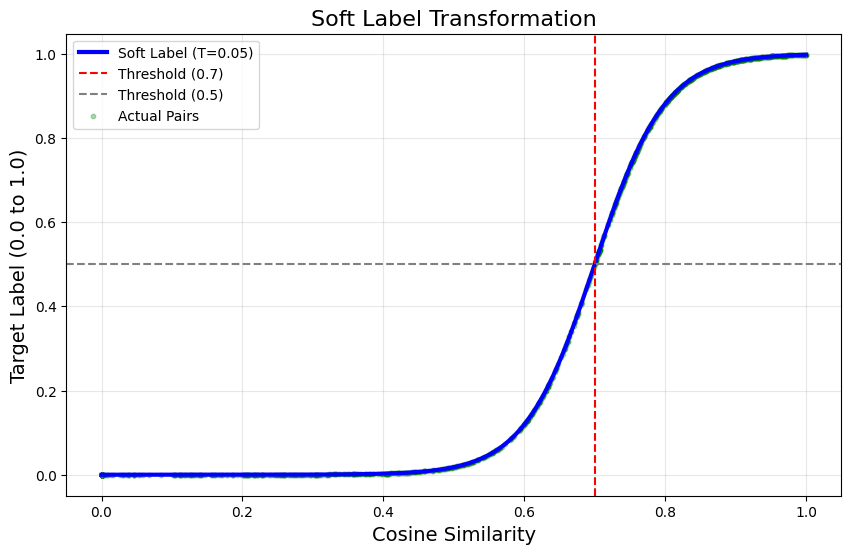

In [5]:
# --- 3. VISUALIZE THE TRANSITION (Sanity Check) ---
print("Generating Visualization...")
plt.figure(figsize=(10, 6))

# Plot the curve
x = np.linspace(0, 1, 500)
y = [get_soft_label(xi) for xi in x]

plt.plot(x, y, label=f"Soft Label (T={TEMPERATURE})", color='blue', linewidth=3)
plt.axvline(THRESHOLD, color='red', linestyle='--', label="Threshold (0.7)")
plt.axhline(PROB_THRESHOLD, color='gray', linestyle='--', label="Threshold (0.5)")

# Plot actual data points (sample)
sample = df.sample(n=1000, random_state=42)
plt.scatter(sample['cosine_similarity'], sample['soft_label'], 
            alpha=0.3, color='green', s=10, label="Actual Pairs")

plt.title("Soft Label Transformation", fontsize=16)
plt.xlabel("Cosine Similarity", fontsize=14)
plt.ylabel("Target Label (0.0 to 1.0)", fontsize=14)
plt.grid(True, alpha=0.3)
plt.legend()
plt.show()

In [6]:
# --- 4. OVERWRITE & SAVE ---
print("Updating Dataset...")
# We overwrite the 'label' column. 
# PyTorch's BCEWithLogitsLoss loves float targets!
df['label'] = df['soft_label'].astype(np.float32)

# Drop the temp column
df = df.drop(columns=['soft_label'])

print(f"Saving to {OUTPUT_PATH}...")
df.to_feather(OUTPUT_PATH)
print("Done.")

Updating Dataset...
Saving to /data/nas-gpu/wang/tmach007/SpectralSimilarityPredictor/data_splits/stratified_binary_07_dataset_train_SOFT_LABELS.feather...
Done.
